In [34]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Transform: convert to [0,1]
transform = transforms.ToTensor()

# 2. Load training dataset
full_train = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# 3. Load test dataset
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 64

# 4. Split train into train/val (80/20)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

# 5. DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Class names
classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
)


In [35]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)      # output: (6, 24, 24)
        self.pool = nn.MaxPool2d(2, 2)       # output: (6, 12, 12)
        self.conv2 = nn.Conv2d(6, 16, 5)     # output: (16, 8, 8)
                                             # pool -> (16, 4, 4)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [36]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # print every 250 mini-batches
        if (i + 1) % 250 == 0:
            print(f"[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss / 250:.3f}")
            running_loss = 0.0

    # -------------------------
    # Validation after each epoch
    # -------------------------
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(loss.item())
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| Val Loss: {avg_val_loss:.3f} "
          f"| Val Acc: {val_acc:.2f}%")

print("Finished Training")


[Epoch 1, Batch 250] loss: 2.301
[Epoch 1, Batch 500] loss: 2.289
[Epoch 1, Batch 750] loss: 2.213
Epoch 1/10 | Val Loss: 2.012 | Val Acc: 43.98%
[Epoch 2, Batch 250] loss: 1.353
[Epoch 2, Batch 500] loss: 0.960
[Epoch 2, Batch 750] loss: 0.851
Epoch 2/10 | Val Loss: 0.831 | Val Acc: 68.02%
[Epoch 3, Batch 250] loss: 0.798
[Epoch 3, Batch 500] loss: 0.731
[Epoch 3, Batch 750] loss: 0.716
Epoch 3/10 | Val Loss: 0.715 | Val Acc: 72.25%
[Epoch 4, Batch 250] loss: 0.673
[Epoch 4, Batch 500] loss: 0.665
[Epoch 4, Batch 750] loss: 0.638
Epoch 4/10 | Val Loss: 0.620 | Val Acc: 76.79%
[Epoch 5, Batch 250] loss: 0.622
[Epoch 5, Batch 500] loss: 0.604
[Epoch 5, Batch 750] loss: 0.597
Epoch 5/10 | Val Loss: 0.617 | Val Acc: 77.08%
[Epoch 6, Batch 250] loss: 0.575
[Epoch 6, Batch 500] loss: 0.568
[Epoch 6, Batch 750] loss: 0.556
Epoch 6/10 | Val Loss: 0.543 | Val Acc: 79.51%
[Epoch 7, Batch 250] loss: 0.536
[Epoch 7, Batch 500] loss: 0.536
[Epoch 7, Batch 750] loss: 0.524
Epoch 7/10 | Val Loss: 0.

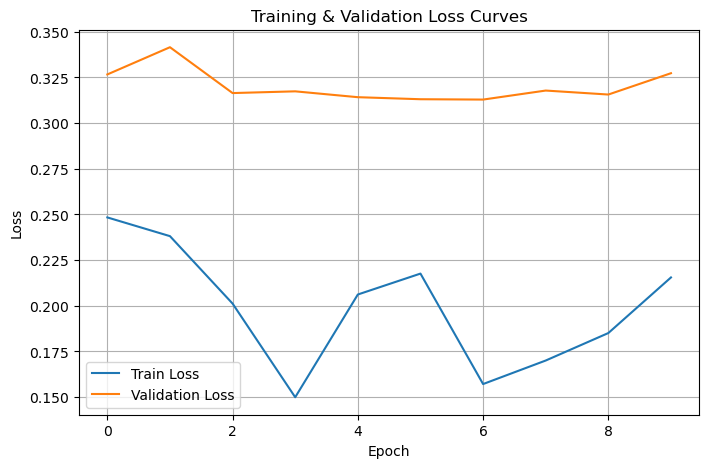

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()



In [9]:
net.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 89.15%


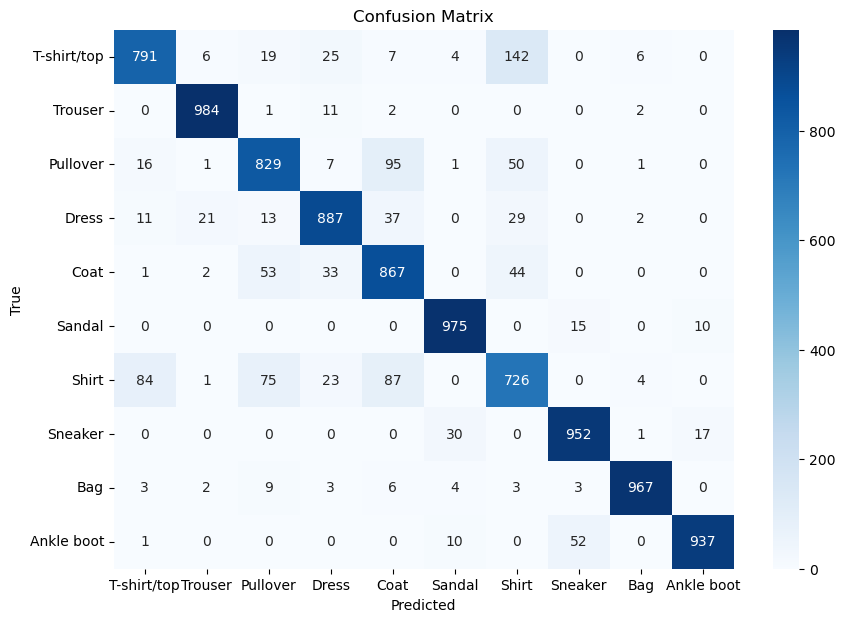

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

confusion_matrix = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
## EXPERIMENTAL

# Added Batch normalization and an additional CNN layer.

import torch.nn as nn
import torch.nn.functional as F
import torch

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # -------------------------
        # Convolutional Block 1
        # -------------------------
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # (32, 28, 28)
        self.bn1   = nn.BatchNorm2d(32)
        
        # -------------------------
        # Convolutional Block 2
        # -------------------------
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (64, 28, 28)
        self.bn2   = nn.BatchNorm2d(64)
        
        # MaxPool → (64, 14, 14)
        self.pool = nn.MaxPool2d(2, 2)

        # -------------------------
        # Convolutional Block 3
        # -------------------------
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (128, 14, 14)
        self.bn3   = nn.BatchNorm2d(128)

        # MaxPool → (128, 7, 7)
        
        # -------------------------
        # Fully Connected Layers
        # -------------------------
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))

        # Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)
        return x

net = Net()
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # print every 250 mini-batches
        if (i + 1) % 250 == 0:
            print(f"[Epoch {epoch+1}, Batch {i+1}] loss: {running_loss / 250:.3f}")
            running_loss = 0.0

    # Validation after each epoch
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(loss.item())
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| Val Loss: {avg_val_loss:.3f} "
          f"| Val Acc: {val_acc:.2f}%")

print("Finished Training")


[Epoch 1, Batch 250] loss: 0.636
[Epoch 1, Batch 500] loss: 0.416
[Epoch 1, Batch 750] loss: 0.368
Epoch 1/10 | Val Loss: 0.323 | Val Acc: 88.02%
[Epoch 2, Batch 250] loss: 0.321
[Epoch 2, Batch 500] loss: 0.310
[Epoch 2, Batch 750] loss: 0.297
Epoch 2/10 | Val Loss: 0.251 | Val Acc: 90.87%
[Epoch 3, Batch 250] loss: 0.264
[Epoch 3, Batch 500] loss: 0.255
[Epoch 3, Batch 750] loss: 0.255
Epoch 3/10 | Val Loss: 0.207 | Val Acc: 92.41%
[Epoch 4, Batch 250] loss: 0.221
[Epoch 4, Batch 500] loss: 0.233
[Epoch 4, Batch 750] loss: 0.219
Epoch 4/10 | Val Loss: 0.241 | Val Acc: 90.88%
[Epoch 5, Batch 250] loss: 0.201
[Epoch 5, Batch 500] loss: 0.204
[Epoch 5, Batch 750] loss: 0.196
Epoch 5/10 | Val Loss: 0.197 | Val Acc: 93.07%
[Epoch 6, Batch 250] loss: 0.176
[Epoch 6, Batch 500] loss: 0.182
[Epoch 6, Batch 750] loss: 0.167
Epoch 6/10 | Val Loss: 0.197 | Val Acc: 92.87%
[Epoch 7, Batch 250] loss: 0.144


In [23]:
PATH = "f_MNIST_net.pth"
torch.save(net.state_dict(), PATH)

net = Net()
net.load_state_dict(torch.load(PATH))
net.eval() 

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 93.07%


My experimental model that differs from the baseline due to it having an extra layer and batch normalization is slightly more accurate based on the test accuracy (93% vs 89%). This is likely because the extra layer allows for the model to capture more abstract/complex features, whereas batch normalization smoothens the gradient.

In [ ]:
import torch
from transformers import pipeline

pipeline = pipeline(task="text-generation", model="openai-community/gpt2", dtype=torch.float16, device=0)
pipeline("Hello, I'm a language model")

In [30]:

from transformers import GPT2LMHeadModel, GPT2TokenizerFast, Trainer, TrainingArguments
from datasets import load_dataset
import torch

# Load jokes dataset 

dataset = load_dataset("csv", data_files="data1.csv")
dataset

#Load tokenizer + model
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2")

# Tokenize dataset
def tokenize(batch):
    tokens = tokenizer(
        batch["Joke"],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokens["labels"] = tokens["input_ids"].copy()   
    return tokens

tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


# Training setup

training_args = TrainingArguments(
    output_dir="./gpt2-jokes",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    logging_steps=50,
    save_steps=500,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
)

# Train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
)

trainer.train()

# Save model + tokenizer
trainer.save_model("./gpt2-jokes-final")
tokenizer.save_pretrained("./gpt2-jokes-final")


# Joke generation

def generate_joke(words):
    prompt = " ".join(words)
    inputs = tokenizer(prompt, return_tensors="pt")

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    output = model.generate(
        **inputs,
        max_length=60,
        temperature=0.9,
        top_p=0.95,
        do_sample=True
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13455.52it/s]


Step,Training Loss
50,3.867911
100,0.652972
150,0.590698
200,0.615520
250,0.602938
300,0.621900
350,0.620278
400,0.669861
450,0.613898
500,0.605992


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


In [33]:
model.config.pad_token_id = tokenizer.eos_token_id

print("Dataset-like prompts:")
print(generate_joke(["why", "did", "the"]))
print(generate_joke(["a", "horse", "walks"]))
print(generate_joke(["how", "many", "programmers"]))

# B. Random prompts
print("\nRandom prompts:")
print(generate_joke(["quantum", "banana", "engineer"]))
print(generate_joke(["blue", "sandwich", "orbit"]))
print(generate_joke(["lava", "piano", "umbrella"]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Dataset-like prompts:
why did the rapper steal the trunk? He didn't belong to rapper.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


a horse walks into a bar... And asks the bartender, "Are you sure you're not a horse?"
how many programmers does it take to change a lightbulb? Tim Beuts!

Random prompts:
quantum banana engineer.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


blue sandwich orbit: 29 degrees, 29 from the Sun.
lava piano umbrella
